In [144]:
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

In [145]:
features_df = pd.read_csv('features.csv')
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')
stores_df = pd.read_csv('stores.csv')

In [146]:
merged_train_stores = train_df.merge(stores_df, on='Store', how='inner')
merged_test_stores = test_df.merge(stores_df, on='Store', how='inner')

train_df_final = merged_train_stores.merge(features_df, on=['Store', 'Date', 'IsHoliday'])
test_df_final = merged_test_stores.merge(features_df, on=['Store', 'Date', 'IsHoliday'])


In [ ]:
# date formatting
train_df_final['Date'] = pd.to_datetime(train_df_final['Date'])
test_df_final['Date'] = pd.to_datetime(test_df_final['Date'])

train_df_final['Month'] = train_df_final['Date'].dt.month
train_df_final['Day'] = train_df_final['Date'].dt.day
train_df_final['dayofweek'] = train_df_final['Date'].dt.dayofweek

test_df_final['Month'] = test_df_final['Date'].dt.month
test_df_final['Day'] = test_df_final['Date'].dt.day
test_df_final['dayofweek'] = test_df_final['Date'].dt.dayofweek



# one hot encoding IsHoliday feature
encoder = OneHotEncoder(sparse_output=False, drop='if_binary')
encoded_train_data = encoder.fit_transform(train_df_final[['IsHoliday', 'Type', 'Dept']])
encoded_test_data = encoder.transform(test_df_final[['IsHoliday', 'Type', 'Dept']])
actual_columns = encoder.get_feature_names_out(['IsHoliday', 'Type', 'Dept'])

train_data = pd.DataFrame(encoded_train_data, index=train_df_final.index, columns=actual_columns)
test_data = pd.DataFrame(encoded_test_data, index=test_df_final.index, columns=actual_columns)

In [ ]:
X_train = pd.concat([train_data, train_df_final.drop(columns=['IsHoliday', 'Type', 'Store', 'Dept'])], axis=1)
X_test = pd.concat([test_data, test_df_final.drop(columns=['IsHoliday', 'Type', 'Store', 'Dept'])], axis=1)

Y_train = X_train[['Weekly_Sales']]
X_train = X_train.drop(columns=['Weekly_Sales', 'Date'])
X_test = X_test.drop(columns=['Date'])

markdown_cols = ['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']
X_train[markdown_cols] = X_train[markdown_cols].fillna(0)
X_test[markdown_cols] = X_test[markdown_cols].fillna(0)


In [149]:
scaler = StandardScaler()
to_scale_cols = []
n = 10

for col in X_train.columns:
    if X_train[col].nunique() > n:
        to_scale_cols.append(col)

scaled_train_features = scaler.fit_transform(X_train[to_scale_cols])
scaled_features_df = pd.DataFrame(scaled_train_features, columns=to_scale_cols, index=X_train.index)
X_train_df = pd.concat([scaled_features_df, X_train.drop(columns=to_scale_cols)], axis=1)

scaled_test_features = scaler.transform(X_test[to_scale_cols])
scaled_test_features_df = pd.DataFrame(scaled_test_features, columns=to_scale_cols, index=X_test.index)
X_test_df = pd.concat([scaled_test_features_df, X_test.drop(columns=to_scale_cols)], axis=1)


X_train_slice, X_test_slice, Y_train_slice, Y_test_slice = train_test_split(X_train_df, Y_train, test_size=.2)
scaler = StandardScaler()
scaled_Y_train_slice = scaler.fit_transform(Y_train_slice)
scaled_Y_test_slice = scaler.transform(Y_test_slice)

In [150]:
input = tf.keras.layers.Input(shape=(X_train_df.shape[1], ))
x = tf.keras.layers.Dense(128, activation='relu')(input)
x = tf.keras.layers.Dense(64, activation='relu')(x)
x = tf.keras.layers.Dense(32, activation='relu')(x)
x = tf.keras.layers.Dense(16, activation='relu')(x)
output = tf.keras.layers.Dense(1, activation='linear')(x)
print(scaled_Y_train_slice[:5, :])

[[ 3.8420388 ]
 [-0.49951726]
 [-0.56161774]
 [-0.69486505]
 [-0.12678579]]


In [151]:
model = tf.keras.models.Model(inputs=input, outputs=output)
model.compile(optimizer='adam', metrics=['mse'], loss='mse')


model.fit(X_train_slice, scaled_Y_train_slice, epochs=5, batch_size=32, validation_split=.2)

Epoch 1/5
8432/8432 ━━━━━━━━━━━━━━━━━━━━ 37s 4ms/step - loss: 0.7781 - mse: 0.7781 - val_loss: 0.6080 - val_mse: 0.6080
Epoch 2/5
8432/8432 ━━━━━━━━━━━━━━━━━━━━ 35s 4ms/step - loss: 0.5459 - mse: 0.5459 - val_loss: 0.5022 - val_mse: 0.5022
Epoch 3/5
8432/8432 ━━━━━━━━━━━━━━━━━━━━ 31s 4ms/step - loss: 0.4787 - mse: 0.4787 - val_loss: 0.4374 - val_mse: 0.4374
Epoch 4/5
8432/8432 ━━━━━━━━━━━━━━━━━━━━ 31s 4ms/step - loss: 0.4541 - mse: 0.4541 - val_loss: 0.4407 - val_mse: 0.4407
Epoch 5/5
8432/8432 ━━━━━━━━━━━━━━━━━━━━ 31s 4ms/step - loss: 0.4396 - mse: 0.4396 - val_loss: 0.4446 - val_mse: 0.4446


In [154]:
Y_pred = model.predict(X_test_slice)

2635/2635 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step


[[ 3.8420388 ]
 [-0.49951726]
 [-0.56161774]
 [-0.69486505]
 [-0.12678579]]
0.5535915223487444


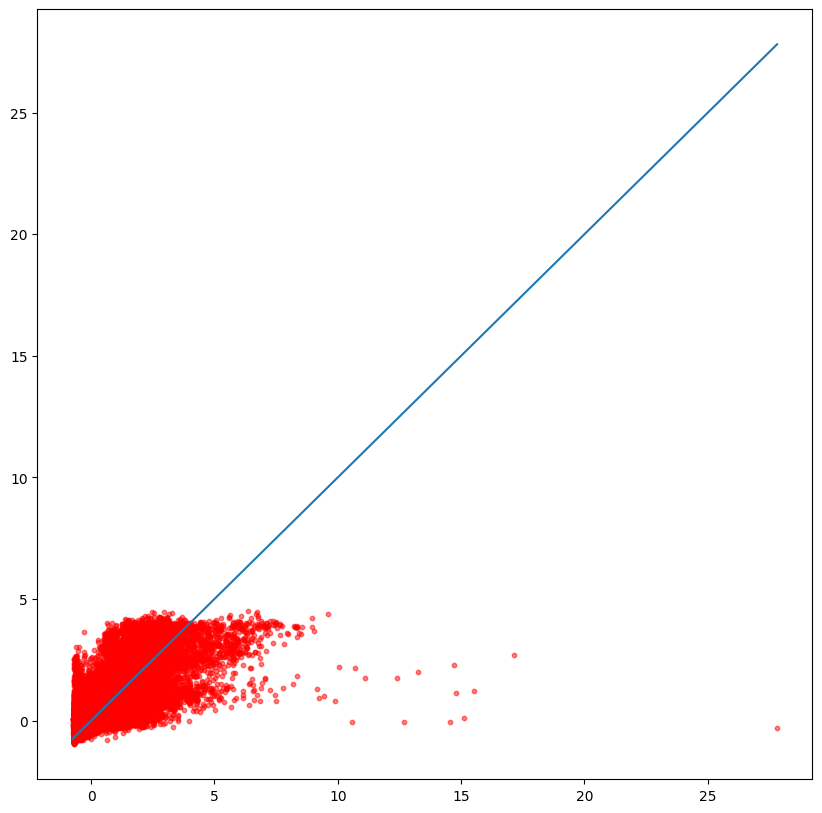

In [159]:
print(scaled_Y_train_slice[:5, :])
r_2 = r2_score(scaled_Y_test_slice, Y_pred)
print(r_2)
plt.figure(figsize=(10, 10))
plt.plot([scaled_Y_test_slice.min(), scaled_Y_test_slice.max()], [scaled_Y_test_slice.min(), scaled_Y_test_slice.max()])
plt.scatter(scaled_Y_test_slice, Y_pred, alpha=.5, s=10, color='red', label='predictions')
plt.show()